In [1]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)


# Imports
from stn_gpe import *
import numpy as np
from matplotlib import pyplot as plt
import scipy
from numpy.fft import fft, ifft
import math
from scipy.signal import spectrogram
from matplotlib.lines import Line2D

from matplotlib.colors import LinearSegmentedColormap
# rc styling (Times New Roman + nicer defaults)
# ...existing code...
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 13,
    "font.weight": "bold",         # global bold
    "axes.titlesize": 13,
    "axes.titleweight": "bold",    # bold axis titles
    "axes.labelsize": 13,
    "axes.labelweight": "bold",    # bold axis labels
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.facecolor": "white",
    "axes.grid": False
})
# ...existing code...
import matplotlib as mpl
mpl.rcParams['ps.fonttype'] = 42

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


## Run STN-GPe system

In [2]:
# Parameters file
yaml_path = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_calibration.yaml')
arguments = load_yaml(yaml_path)


In [3]:
arguments_low_lateral_strength = arguments.copy()
arguments_low_lateral_strength['lat_strength_stn'] = 0.02
arguments_low_lateral_strength['I_strd2_gpe'] = 5
arguments_low_lateral_strength['stn_gpe_noise'] = 3
# save yaml as temp.yaml in temp folder
save_yaml(arguments_low_lateral_strength, os.path.join(project_root, 'temp', 'temp.yaml'))

# Simulate STN-GPe system
results_low_lateral_strength = STN_GPe_loop(os.path.join(project_root, 'temp', 'temp.yaml'))

  0%|          | 0/50000 [00:00<?, ?it/s]

In [4]:
arguments_high_lateral_strength = arguments.copy()
arguments_high_lateral_strength['lat_strength_stn'] = 0.0275
arguments_high_lateral_strength['I_strd2_gpe'] = 5
arguments_high_lateral_strength['stn_gpe_noise'] = 0
# save yaml as temp.yaml in temp folder
save_yaml(arguments_high_lateral_strength, os.path.join(project_root, 'temp', 'temp.yaml'))

# Simulate STN-GPe system
results_high_lateral_strength = STN_GPe_loop(os.path.join(project_root, 'temp', 'temp.yaml'))

  0%|          | 0/50000 [00:00<?, ?it/s]

In [5]:
arguments_low_curr = arguments.copy()
arguments_low_curr['lat_strength_stn'] = 0.0275
arguments_low_curr['I_strd2_gpe'] = 0.5
arguments_low_curr['stn_gpe_noise'] = 3
# save yaml as temp.yaml in temp folder
save_yaml(arguments_low_curr, os.path.join(project_root, 'temp', 'temp.yaml'))

# Simulate STN-GPe system
results_low_curr = STN_GPe_loop(os.path.join(project_root, 'temp', 'temp.yaml'))

  0%|          | 0/50000 [00:00<?, ?it/s]

In [6]:
arguments_high_curr = arguments.copy()
arguments_high_curr['lat_strength_stn'] = 0.0275
arguments_high_curr['I_strd2_gpe'] = 5
arguments_high_curr['stn_gpe_noise'] = 0
# save yaml as temp.yaml in temp folder
save_yaml(arguments_high_curr, os.path.join(project_root, 'temp', 'temp.yaml'))

# Simulate STN-GPe system
results_high_curr = STN_GPe_loop(os.path.join(project_root, 'temp', 'temp.yaml'))

  0%|          | 0/50000 [00:00<?, ?it/s]

## Analysis

In [7]:
V_stn_time_all_low_lateral_strength = np.array(results_low_lateral_strength['v_stn'])
V_gpe_time_all_low_lateral_strength = np.array(results_low_lateral_strength['v_gpe'])
spike_monitor_stn_low_lateral_strength = results_low_lateral_strength['spike_stn']
spike_monitor_gpe_low_lateral_strength = results_low_lateral_strength['spike_gpe']
lfp_stn_low_lateral_strength = results_low_lateral_strength['lfp_stn']
lfp_gpe_low_lateral_strength = results_low_lateral_strength['lfp_gpe']


V_stn_time_all_high_lateral_strength = np.array(results_high_lateral_strength['v_stn'])
V_gpe_time_all_high_lateral_strength = np.array(results_high_lateral_strength['v_gpe'])
spike_monitor_stn_high_lateral_strength = results_high_lateral_strength['spike_stn']
spike_monitor_gpe_high_lateral_strength = results_high_lateral_strength['spike_gpe']
lfp_stn_high_lateral_strength = results_high_lateral_strength['lfp_stn']
lfp_gpe_high_lateral_strength = results_high_lateral_strength['lfp_gpe']


V_stn_time_all_low_curr = np.array(results_low_curr['v_stn'])
V_gpe_time_all_low_curr = np.array(results_low_curr['v_gpe'])
spike_monitor_stn_low_curr = results_low_curr['spike_stn']
spike_monitor_gpe_low_curr = results_low_curr['spike_gpe']
lfp_stn_low_curr = results_low_curr['lfp_stn']
lfp_gpe_low_curr = results_low_curr['lfp_gpe']



V_stn_time_all_high_curr = np.array(results_high_curr['v_stn'])
V_gpe_time_all_high_curr = np.array(results_high_curr['v_gpe'])
spike_monitor_stn_high_curr = results_high_curr['spike_stn']
spike_monitor_gpe_high_curr = results_high_curr['spike_gpe']
lfp_stn_high_curr = results_high_curr['lfp_stn']
lfp_gpe_high_curr = results_high_curr['lfp_gpe']

In [8]:
iter_low_lateral_strength = arguments_low_lateral_strength.get('time')
h_low_lateral_strength = arguments_low_lateral_strength.get('dt')
t_low_low_lateral_strength = 30000
t_high_low_lateral_strength = 50000
t_chunk_low_lateral_strength = np.linspace(0,(t_high_low_lateral_strength-t_low_low_lateral_strength)*h_low_lateral_strength/1000,t_high_low_lateral_strength - t_low_low_lateral_strength)
t_low_lateral_strength = np.linspace(0,iter_low_lateral_strength*h_low_lateral_strength/1000,iter_low_lateral_strength)


#************************Analysis**************************************
analysis_STN_low_lateral_strength = Analysis(spike_monitor_stn_low_lateral_strength[t_low_low_lateral_strength:t_high_low_lateral_strength])
analysis_GPe_low_lateral_strength = Analysis(spike_monitor_gpe_low_lateral_strength[t_low_low_lateral_strength:t_high_low_lateral_strength])


# ************************* FFT ***************************************
lfp_smooth_stn_low_lateral_strength = scipy.signal.savgol_filter(lfp_stn_low_lateral_strength[t_low_low_lateral_strength-10000:t_high_low_lateral_strength], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
lfp_smooth_gpe_low_lateral_strength = scipy.signal.savgol_filter(lfp_gpe_low_lateral_strength[t_low_low_lateral_strength-10000:t_high_low_lateral_strength], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
sr_low_lateral_strength = 10000
fft_output_stn_low_lateral_strength = fft(lfp_stn_low_lateral_strength)
fft_output_gpe_low_lateral_strength = fft(lfp_smooth_gpe_low_lateral_strength)
N_low_lateral_strength = len(fft_output_stn_low_lateral_strength)
n_low_lateral_strength = np.arange(N_low_lateral_strength)
T_low_lateral_strength = N_low_lateral_strength/sr_low_lateral_strength
freq_low_lateral_strength = n_low_lateral_strength/T_low_lateral_strength

# ***********************Spectrogram***********************************
fs_low_lateral_strength = 10000  # sampling frequency
window_size_low_lateral_strength = 10000 #10000  # 100ms window
overlap_low_lateral_strength = 950 
nperseg_low_lateral_strength = window_size_low_lateral_strength
noverlap_low_lateral_strength = overlap_low_lateral_strength

# STN Spectrogram
f_stn_low_lateral_strength, t_spec_stn_low_lateral_strength, Sxx_stn_low_lateral_strength = scipy.signal.spectrogram(lfp_smooth_stn_low_lateral_strength, fs=fs_low_lateral_strength, 
                                                      nperseg=nperseg_low_lateral_strength, 
                                                      noverlap=noverlap_low_lateral_strength, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'

# GPe Spectrogram
f_gpe_low_lateral_strength, t_spec_gpe_low_lateral_strength, Sxx_gpe_low_lateral_strength = scipy.signal.spectrogram(lfp_smooth_gpe_low_lateral_strength, fs=fs_low_lateral_strength, 
                                                      nperseg=nperseg_low_lateral_strength, 
                                                      noverlap=noverlap_low_lateral_strength, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'


# **************************Spectral entropy***************************
avg_entropy_stn_low_lateral_strength = analysis_STN_low_lateral_strength.spectral_entropy(signal=lfp_stn_low_lateral_strength[t_low_low_lateral_strength:t_high_low_lateral_strength],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)
avg_entropy_gpe_low_lateral_strength = analysis_GPe_low_lateral_strength.spectral_entropy(signal=lfp_gpe_low_lateral_strength[t_low_low_lateral_strength:t_high_low_lateral_strength],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)


# ***************************Synchrony********************************
R_sync_stn_low_lateral_strength, Ravg_stn_low_lateral_strength = analysis_STN_low_lateral_strength.synchrony()
R_sync_gpe_low_lateral_strength, Ravg_gpe_low_lateral_strength = analysis_GPe_low_lateral_strength.synchrony()


# **************************Rate Output******************************
# spike to rate conversion
rate_data_low_lateral_strength = analysis_STN_low_lateral_strength.spike_rate(binsize = 100)

# stn_a_low_lateral_strength, stn_b_low_lateral_strength, stn_c_low_lateral_strength, stn_d_low_lateral_strength = rate_data_low_lateral_strength['1'], rate_data_low_lateral_strength['2'], rate_data_low_lateral_strength['3'], rate_data_low_lateral_strength['4']
rate_all_low_lateral_strength = rate_data_low_lateral_strength['raw_rate_data']
preprocessed_stn_low_lateral_strength = rate_data_low_lateral_strength['preprocessed_rate_data']
processed_stn_low_lateral_strength = rate_data_low_lateral_strength['processed_rate_data']
rescaled_stn_low_lateral_strength = rate_data_low_lateral_strength['rescaled_rate_data']
mean_std_low_lateral_strength = rate_data_low_lateral_strength['mean_std']
max_std_low_lateral_strength = rate_data_low_lateral_strength['max_std']
min_std_low_lateral_strength = rate_data_low_lateral_strength['min_std']

#**************************Frequency*******************************
frequency_avg_STN_low_lateral_strength, frequency_max_STN_low_lateral_strength, frequency_min_STN_low_lateral_strength = analysis_STN_low_lateral_strength.frequency(dt = h_low_lateral_strength)

frequency_avg_GPe_low_lateral_strength, frequency_max_GPe_low_lateral_strength, frequency_min_GPe_low_lateral_strength = analysis_GPe_low_lateral_strength.frequency(dt = h_low_lateral_strength)


In [9]:
iter_high_lateral_strength = arguments_high_lateral_strength.get('time')
h_high_lateral_strength = arguments_high_lateral_strength.get('dt')
t_low_high_lateral_strength = 30000
t_high_high_lateral_strength = 50000
t_chunk_high_lateral_strength = np.linspace(0,(t_high_high_lateral_strength-t_low_high_lateral_strength)*h_high_lateral_strength/1000,t_high_high_lateral_strength - t_low_high_lateral_strength)
t_high_lateral_strength = np.linspace(0,iter_high_lateral_strength*h_high_lateral_strength/1000,iter_high_lateral_strength)


#************************Analysis**************************************
analysis_STN_high_lateral_strength = Analysis(spike_monitor_stn_high_lateral_strength[t_low_high_lateral_strength:t_high_high_lateral_strength])
analysis_GPe_high_lateral_strength = Analysis(spike_monitor_gpe_high_lateral_strength[t_low_high_lateral_strength:t_high_high_lateral_strength])


# ************************* FFT ***************************************
lfp_smooth_stn_high_lateral_strength = scipy.signal.savgol_filter(lfp_stn_high_lateral_strength[t_low_high_lateral_strength-10000:t_high_high_lateral_strength], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
lfp_smooth_gpe_high_lateral_strength = scipy.signal.savgol_filter(lfp_gpe_high_lateral_strength[t_low_high_lateral_strength-10000:t_high_high_lateral_strength], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
sr_high_lateral_strength = 10000
fft_output_stn_high_lateral_strength = fft(lfp_stn_high_lateral_strength)
fft_output_gpe_high_lateral_strength = fft(lfp_smooth_gpe_high_lateral_strength)
N_high_lateral_strength = len(fft_output_stn_high_lateral_strength)
n_high_lateral_strength = np.arange(N_high_lateral_strength)
T_high_lateral_strength = N_high_lateral_strength/sr_high_lateral_strength
freq_high_lateral_strength = n_high_lateral_strength/T_high_lateral_strength

# ***********************Spectrogram***********************************
fs_high_lateral_strength = 10000  # sampling frequency
window_size_high_lateral_strength = 10000 #10000  # 100ms window
overlap_high_lateral_strength = 950 
nperseg_high_lateral_strength = window_size_high_lateral_strength
noverlap_high_lateral_strength = overlap_high_lateral_strength

# STN Spectrogram
f_stn_high_lateral_strength, t_spec_stn_high_lateral_strength, Sxx_stn_high_lateral_strength = scipy.signal.spectrogram(lfp_smooth_stn_high_lateral_strength, fs=fs_high_lateral_strength, 
                                                      nperseg=nperseg_high_lateral_strength, 
                                                      noverlap=noverlap_high_lateral_strength, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'

# GPe Spectrogram
f_gpe_high_lateral_strength, t_spec_gpe_high_lateral_strength, Sxx_gpe_high_lateral_strength = scipy.signal.spectrogram(lfp_smooth_gpe_high_lateral_strength, fs=fs_high_lateral_strength, 
                                                      nperseg=nperseg_high_lateral_strength, 
                                                      noverlap=noverlap_high_lateral_strength, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'


# **************************Spectral entropy***************************
avg_entropy_stn_high_lateral_strength = analysis_STN_high_lateral_strength.spectral_entropy(signal=lfp_stn_high_lateral_strength[t_low_high_lateral_strength:t_high_high_lateral_strength],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)
avg_entropy_gpe_high_lateral_strength = analysis_GPe_high_lateral_strength.spectral_entropy(signal=lfp_gpe_high_lateral_strength[t_low_high_lateral_strength:t_high_high_lateral_strength],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)


# ***************************Synchrony********************************
R_sync_stn_high_lateral_strength, Ravg_stn_high_lateral_strength = analysis_STN_high_lateral_strength.synchrony()
R_sync_gpe_high_lateral_strength, Ravg_gpe_high_lateral_strength = analysis_GPe_high_lateral_strength.synchrony()


# **************************Rate Output******************************
# spike to rate conversion
rate_data_high_lateral_strength = analysis_STN_high_lateral_strength.spike_rate(binsize = 100)

# stn_a_high_lateral_strength, stn_b_high_lateral_strength, stn_c_high_lateral_strength, stn_d_high_lateral_strength = rate_data_high_lateral_strength['1'], rate_data_high_lateral_strength['2'], rate_data_high_lateral_strength['3'], rate_data_high_lateral_strength['4']
rate_all_high_lateral_strength = rate_data_high_lateral_strength['raw_rate_data']
preprocessed_stn_high_lateral_strength = rate_data_high_lateral_strength['preprocessed_rate_data']
processed_stn_high_lateral_strength = rate_data_high_lateral_strength['processed_rate_data']
rescaled_stn_high_lateral_strength = rate_data_high_lateral_strength['rescaled_rate_data']
mean_std_high_lateral_strength = rate_data_high_lateral_strength['mean_std']
max_std_high_lateral_strength = rate_data_high_lateral_strength['max_std']
min_std_high_lateral_strength = rate_data_high_lateral_strength['min_std']

#**************************Frequency*******************************
frequency_avg_STN_high_lateral_strength, frequency_max_STN_high_lateral_strength, frequency_min_STN_high_lateral_strength = analysis_STN_high_lateral_strength.frequency(dt = h_high_lateral_strength)

frequency_avg_GPe_high_lateral_strength, frequency_max_GPe_high_lateral_strength, frequency_min_GPe_high_lateral_strength = analysis_GPe_high_lateral_strength.frequency(dt = h_high_lateral_strength)


In [10]:
iter_low_curr = arguments_low_curr.get('time')
h_low_curr = arguments_low_curr.get('dt')
t_low_low_curr = 30000
t_high_low_curr = 50000
t_chunk_low_curr = np.linspace(0,(t_high_low_curr-t_low_low_curr)*h_low_curr/1000,t_high_low_curr - t_low_low_curr)
t_low_curr = np.linspace(0,iter_low_curr*h_low_curr/1000,iter_low_curr)


#************************Analysis**************************************
analysis_STN_low_curr = Analysis(spike_monitor_stn_low_curr[t_low_low_curr:t_high_low_curr])
analysis_GPe_low_curr = Analysis(spike_monitor_gpe_low_curr[t_low_low_curr:t_high_low_curr])


# ************************* FFT ***************************************
lfp_smooth_stn_low_curr = scipy.signal.savgol_filter(lfp_stn_low_curr[t_low_low_curr-10000:t_high_low_curr], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
lfp_smooth_gpe_low_curr = scipy.signal.savgol_filter(lfp_gpe_low_curr[t_low_low_curr-10000:t_high_low_curr], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
sr_low_curr = 10000
fft_output_stn_low_curr = fft(lfp_stn_low_curr)
fft_output_gpe_low_curr = fft(lfp_smooth_gpe_low_curr)
N_low_curr = len(fft_output_stn_low_curr)
n_low_curr = np.arange(N_low_curr)
T_low_curr = N_low_curr/sr_low_curr
freq_low_curr = n_low_curr/T_low_curr

# ***********************Spectrogram***********************************
fs_low_curr = 10000  # sampling frequency
window_size_low_curr = 10000 #10000  # 100ms window
overlap_low_curr = 950 
nperseg_low_curr = window_size_low_curr
noverlap_low_curr = overlap_low_curr

# STN Spectrogram
f_stn_low_curr, t_spec_stn_low_curr, Sxx_stn_low_curr = scipy.signal.spectrogram(lfp_smooth_stn_low_curr, fs=fs_low_curr, 
                                                      nperseg=nperseg_low_curr, 
                                                      noverlap=noverlap_low_curr, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'

# GPe Spectrogram
f_gpe_low_curr, t_spec_gpe_low_curr, Sxx_gpe_low_curr = scipy.signal.spectrogram(lfp_smooth_gpe_low_curr, fs=fs_low_curr, 
                                                      nperseg=nperseg_low_curr, 
                                                      noverlap=noverlap_low_curr, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'


# **************************Spectral entropy***************************
avg_entropy_stn_low_curr = analysis_STN_low_curr.spectral_entropy(signal=lfp_stn_low_curr[t_low_low_curr:t_high_low_curr],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)
avg_entropy_gpe_low_curr = analysis_GPe_low_curr.spectral_entropy(signal=lfp_gpe_low_curr[t_low_low_curr:t_high_low_curr],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)


# ***************************Synchrony********************************
R_sync_stn_low_curr, Ravg_stn_low_curr = analysis_STN_low_curr.synchrony()
R_sync_gpe_low_curr, Ravg_gpe_low_curr = analysis_GPe_low_curr.synchrony()


# **************************Rate Output******************************
# spike to rate conversion
rate_data_low_curr = analysis_STN_low_curr.spike_rate(binsize = 100)

# stn_a_low_curr, stn_b_low_curr, stn_c_low_curr, stn_d_low_curr = rate_data_low_curr['1'], rate_data_low_curr['2'], rate_data_low_curr['3'], rate_data_low_curr['4']
rate_all_low_curr = rate_data_low_curr['raw_rate_data']
preprocessed_stn_low_curr = rate_data_low_curr['preprocessed_rate_data']
processed_stn_low_curr = rate_data_low_curr['processed_rate_data']
rescaled_stn_low_curr = rate_data_low_curr['rescaled_rate_data']
mean_std_low_curr = rate_data_low_curr['mean_std']
max_std_low_curr = rate_data_low_curr['max_std']
min_std_low_curr = rate_data_low_curr['min_std']

#**************************Frequency*******************************
frequency_avg_STN_low_curr, frequency_max_STN_low_curr, frequency_min_STN_low_curr = analysis_STN_low_curr.frequency(dt = h_low_curr)

frequency_avg_GPe_low_curr, frequency_max_GPe_low_curr, frequency_min_GPe_low_curr = analysis_GPe_low_curr.frequency(dt = h_low_curr)


In [11]:
iter_high_curr = arguments_high_curr.get('time')
h_high_curr = arguments_high_curr.get('dt')
t_low_high_curr = 30000
t_high_high_curr = 50000
t_chunk_high_curr = np.linspace(0,(t_high_high_curr-t_low_high_curr)*h_high_curr/1000,t_high_high_curr - t_low_high_curr)
t_high_curr = np.linspace(0,iter_high_curr*h_high_curr/1000,iter_high_curr)


#************************Analysis**************************************
analysis_STN_high_curr = Analysis(spike_monitor_stn_high_curr[t_low_high_curr:t_high_high_curr])
analysis_GPe_high_curr = Analysis(spike_monitor_gpe_high_curr[t_low_high_curr:t_high_high_curr])


# ************************* FFT ***************************************
lfp_smooth_stn_high_curr = scipy.signal.savgol_filter(lfp_stn_high_curr[t_low_high_curr-10000:t_high_high_curr], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
lfp_smooth_gpe_high_curr = scipy.signal.savgol_filter(lfp_gpe_high_curr[t_low_high_curr-10000:t_high_high_curr], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
sr_high_curr = 10000
fft_output_stn_high_curr = fft(lfp_stn_high_curr)
fft_output_gpe_high_curr = fft(lfp_smooth_gpe_high_curr)
N_high_curr = len(fft_output_stn_high_curr)
n_high_curr = np.arange(N_high_curr)
T_high_curr = N_high_curr/sr_high_curr
freq_high_curr = n_high_curr/T_high_curr

# ***********************Spectrogram***********************************
fs_high_curr = 10000  # sampling frequency
window_size_high_curr = 10000 #10000  # 100ms window
overlap_high_curr = 950 
nperseg_high_curr = window_size_high_curr
noverlap_high_curr = overlap_high_curr

# STN Spectrogram
f_stn_high_curr, t_spec_stn_high_curr, Sxx_stn_high_curr = scipy.signal.spectrogram(lfp_smooth_stn_high_curr, fs=fs_high_curr, 
                                                      nperseg=nperseg_high_curr, 
                                                      noverlap=noverlap_high_curr, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'

# GPe Spectrogram
f_gpe_high_curr, t_spec_gpe_high_curr, Sxx_gpe_high_curr = scipy.signal.spectrogram(lfp_smooth_gpe_high_curr, fs=fs_high_curr, 
                                                      nperseg=nperseg_high_curr, 
                                                      noverlap=noverlap_high_curr, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'


# **************************Spectral entropy***************************
avg_entropy_stn_high_curr = analysis_STN_high_curr.spectral_entropy(signal=lfp_stn_high_curr[t_low_high_curr:t_high_high_curr],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)
avg_entropy_gpe_high_curr = analysis_GPe_high_curr.spectral_entropy(signal=lfp_gpe_high_curr[t_low_high_curr:t_high_high_curr],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 35,
                                   normalize = True)


# ***************************Synchrony********************************
R_sync_stn_high_curr, Ravg_stn_high_curr = analysis_STN_high_curr.synchrony()
R_sync_gpe_high_curr, Ravg_gpe_high_curr = analysis_GPe_high_curr.synchrony()


# **************************Rate Output******************************
# spike to rate conversion
rate_data_high_curr = analysis_STN_high_curr.spike_rate(binsize = 100)

# stn_a_high_curr, stn_b_high_curr, stn_c_high_curr, stn_d_high_curr = rate_data_high_curr['1'], rate_data_high_curr['2'], rate_data_high_curr['3'], rate_data_high_curr['4']
rate_all_high_curr = rate_data_high_curr['raw_rate_data']
preprocessed_stn_high_curr = rate_data_high_curr['preprocessed_rate_data']
processed_stn_high_curr = rate_data_high_curr['processed_rate_data']
rescaled_stn_high_curr = rate_data_high_curr['rescaled_rate_data']
mean_std_high_curr = rate_data_high_curr['mean_std']
max_std_high_curr = rate_data_high_curr['max_std']
min_std_high_curr = rate_data_high_curr['min_std']

#**************************Frequency*******************************
frequency_avg_STN_high_curr, frequency_max_STN_high_curr, frequency_min_STN_high_curr = analysis_STN_high_curr.frequency(dt = h_high_curr)

frequency_avg_GPe_high_curr, frequency_max_GPe_high_curr, frequency_min_GPe_high_curr = analysis_GPe_high_curr.frequency(dt = h_high_curr)


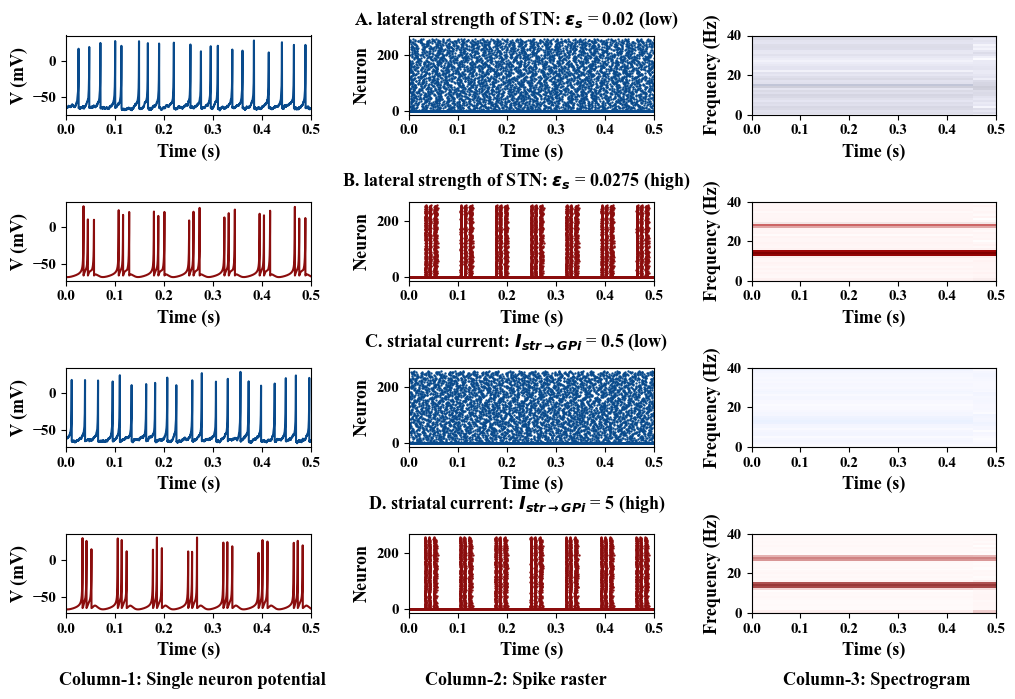

In [12]:
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ======================================================
# COLOR SYSTEM
# ======================================================

colors = {
    "current": {
        "low":  "#084a8c",   # light red
        "high": "#8b0d0d",   # dark red
        # "low":  "#7fb9e6",   # light blue
        # "high": "#f2a3a3",   # dark blue
    },
    "lateral": {
        "low":  "#084a8c",   # light red
        "high": "#8b0d0d",   # dark red
    }
}

# ======================================================
# COLORMAP SYSTEM (simplified)
# ======================================================


colors_blue = [
    (1, 1, 1),        # Pure white
    (0.98, 0.98, 1),  # Almost white with tiny blue tint
    # (0.95, 0.95, 1),  # Very slight blue tint
    (0.9, 0.9, 0.95), # Very slight blue tint,
    (0.8, 0.8, 0.85),
    (0.05, 0.3, 0.7), # Dark blue
    (0, 0.1, 0.5)     # Darker blue
]
cmap_blue = LinearSegmentedColormap.from_list('custom_blues', colors_blue)


colors_red = [
    (1, 1, 1),        # Pure white
    (1, 0.98, 0.98),  # Almost white with tiny red tint
    (1, 0.95, 0.95),  # Very slight red tint
    (0.95, 0.9, 0.9),
    (0.7, 0.05, 0.05), # Dark red
    (0.5, 0, 0)       # Darker red
]
cmap_red = LinearSegmentedColormap.from_list('custom_reds', colors_red)


# ======================================================
# LIGHT COLORMAPS (low-condition spectrograms)
# ======================================================

colors_light_blue = [
    (1, 1, 1),
    (0.99, 0.99, 1.0),
    (0.97, 0.97, 1.0),
    (0.93, 0.95, 1.0),
    (0.85, 0.9, 1.0),
    (0.65, 0.8, 0.95)
]

cmap_light_blue = LinearSegmentedColormap.from_list(
    "light_blue", colors_light_blue
)

colors_light_red = [
    (1.0, 1.0, 1.0),
    (1.0, 0.99, 0.99),
    (1.0, 0.96, 0.96),
    (0.88, 0.65, 0.65),
    (0.75, 0.40, 0.40),
    (0.60, 0.22, 0.22)
]

cmap_light_red = LinearSegmentedColormap.from_list(
    "brick_red", colors_light_red
)



# ======================================================
# COMMON SPECTROGRAM NORMALIZATION
# ======================================================

pd_spec_db = 10 * np.log10(Sxx_stn_high_lateral_strength + 1e-16)

freq_mask = f_stn_high_lateral_strength <= 40
pd_vals = pd_spec_db[freq_mask, :].ravel() if np.any(freq_mask) else pd_spec_db.ravel()

common_norm = Normalize(
    vmin=np.nanmin(pd_vals),
    vmax=np.nanmax(pd_vals)
)

# ======================================================
# FIGURE
# ======================================================

fig, axs = plt.subplots(
    4, 3, figsize=(12, 7.5),
    facecolor="white",
    gridspec_kw={"height_ratios": [1, 1, 1, 1]}
)

# ======================================================
# CENTERED ROW TITLES (figure-level)
# ======================================================

row_titles = [
    r"A. lateral strength of STN: $\epsilon_s$ = 0.02 (low)",
    r"B. lateral strength of STN: $\epsilon_s$ = 0.0275 (high)",
    r"C. striatal current: $I_{str \rightarrow GPi}$ = 0.5 (low)",
    r"D. striatal current: $I_{str \rightarrow GPi}$ = 5 (high)"
]

for i, title in enumerate(row_titles):
    fig.text(
        0.5,                     # center horizontally
        0.9 - i * 0.215,        # vertical placement per row
        title,
        ha="center",
        va="center",
        # fontsize=13,
        fontweight="bold"
    )

# ======================================================
# -------- ROW 1: LOW LATERAL --------------------------
# ======================================================

axs[0, 0].plot(
    t_chunk_low_lateral_strength,
    V_stn_time_all_low_lateral_strength[
        t_low_low_lateral_strength:t_high_low_lateral_strength, 15, 15
    ],
    color=colors["lateral"]["low"]
)

spikes = np.array(
    spike_monitor_stn_low_lateral_strength[
        t_low_low_lateral_strength:t_high_low_lateral_strength
    ]
)

t_raster = np.linspace(
    0, spikes.shape[0] * h_low_lateral_strength / 1000,
    spikes.shape[0]
)

for n in range(spikes.shape[1]):
    axs[0, 1].scatter(
        t_raster, (n + 1) * spikes[:, n],
        s=0.5,
        color=colors["lateral"]["low"]
    )

axs[0, 2].pcolormesh(
    t_spec_stn_low_lateral_strength,
    f_stn_low_lateral_strength,
    10 * np.log10(Sxx_stn_low_lateral_strength + 1e-16),
    cmap=cmap_blue,
    shading="auto",
    norm=common_norm,
    rasterized=True
)

# ======================================================
# -------- ROW 2: HIGH LATERAL -------------------------
# ======================================================

axs[1, 0].plot(
    t_chunk_high_lateral_strength,
    V_stn_time_all_high_lateral_strength[
        t_low_high_lateral_strength:t_high_high_lateral_strength, 15, 15
    ],
    color=colors["lateral"]["high"]
)

spikes = np.array(
    spike_monitor_stn_high_lateral_strength[
        t_low_high_lateral_strength:t_high_high_lateral_strength
    ]
)

t_raster = np.linspace(
    0, spikes.shape[0] * h_high_lateral_strength / 1000,
    spikes.shape[0]
)

for n in range(spikes.shape[1]):
    axs[1, 1].scatter(
        t_raster, (n + 1) * spikes[:, n],
        s=0.5,
        color=colors["lateral"]["high"]
    )

axs[1, 2].pcolormesh(
    t_spec_stn_high_lateral_strength,
    f_stn_high_lateral_strength,
    10 * np.log10(Sxx_stn_high_lateral_strength+ 1e-16),
    cmap=cmap_red,
    shading="auto",
    norm=common_norm,
    rasterized=True
)

# ======================================================
# -------- ROW 3: LOW CURRENT --------------------------
# ======================================================

axs[2, 0].plot(
    t_chunk_low_curr,
    V_stn_time_all_low_curr[t_low_low_curr:t_high_low_curr, 15, 15],
    color=colors["current"]["low"]
)

spikes = np.array(
    spike_monitor_stn_low_curr[t_low_low_curr:t_high_low_curr]
)

t_raster = np.linspace(
    0, spikes.shape[0] * h_low_curr / 1000,
    spikes.shape[0]
)

for n in range(spikes.shape[1]):
    axs[2, 1].scatter(
        t_raster, (n + 1) * spikes[:, n],
        s=0.5,
        color=colors["current"]["low"]
    )

axs[2, 2].pcolormesh(
    t_spec_stn_low_curr,
    f_stn_low_curr,
    10 * np.log10(Sxx_stn_low_curr+ 1e-16),
    cmap=cmap_light_blue,
    shading="auto",
    norm=common_norm,
    rasterized=True
)

# ======================================================
# -------- ROW 4: HIGH CURRENT -------------------------
# ======================================================

axs[3, 0].plot(
    t_chunk_high_curr,
    V_stn_time_all_high_curr[t_low_high_curr:t_high_high_curr, 15, 15],
    color=colors["current"]["high"]
)

spikes = np.array(
    spike_monitor_stn_high_curr[t_low_high_curr:t_high_high_curr]
)

t_raster = np.linspace(
    0, spikes.shape[0] * h_high_curr / 1000,
    spikes.shape[0]
)

for n in range(spikes.shape[1]):
    axs[3, 1].scatter(
        t_raster, (n + 1) * spikes[:, n],
        s=0.5,
        color=colors["current"]["high"]
    )

axs[3, 2].pcolormesh(
    t_spec_stn_high_curr,
    f_stn_high_curr,
    10 * np.log10(Sxx_stn_high_curr+ 1e-16),
    cmap=cmap_light_red,
    shading="auto",
    norm=common_norm,
    rasterized=True
)

# ======================================================
# AXES FORMATTING
# ======================================================

for ax in axs[:, :2].flat:
    ax.set_xlim(0, 0.5)

for ax in axs[:, 2]:
    ax.set_xlim(0.5, 1)
    ax.set_ylim(0, 40)

for ax in axs.flat:
    ax.set_xlabel("Time (s)")

for i in range(4):
    axs[i, 0].set_ylabel("V (mV)")
    axs[i, 1].set_ylabel("Neuron")
    axs[i, 2].set_ylabel("Frequency (Hz)")


# remap time ticks for all spectrograms (3rd column)
tick_positions = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
tick_labels   = ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5"]

for ax in axs[:, 2]:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)




column_titles = [
    "Column-1: Single neuron potential",
    "Column-2: Spike raster",
    "Column-3: Spectrogram"
]


# x positions of the 3 columns (figure coordinates)
x_positions = [0.18, 0.45, 0.75]

for x, title in zip(x_positions, column_titles):
    fig.text(
        x+ 0.05,
        0.02,             
        title,
        ha="center",
        va="center",
        # fontsize=13,
        fontweight="bold"
    )

for ax in axs[:, 2]:
    ax.set_rasterization_zorder(0)



plt.subplots_adjust(wspace=0.4, hspace=1.1)


# Save figs
fig.set_rasterized(True)
# plt.savefig("STN_GPe_calibration.svg", format="svg",  bbox_inches="tight",pad_inches=0.05)
# plt.savefig("STN_GPe_calibration.png", format="png", bbox_inches="tight",pad_inches=0.05)
# plt.savefig("STN_GPe_calibration.pdf", format="pdf", bbox_inches="tight",pad_inches=0.05)
# plt.savefig("STN_GPe_calibration.tiff",format="tiff",dpi=600,bbox_inches="tight",pad_inches=0.05)
# plt.savefig("STN_GPe_calibration.eps",format="eps",bbox_inches="tight",pad_inches=0.05)

plt.show()


In [13]:
# Print metrics in table format
print(f'|{"Metric":<15}|{"low lat":^10}|{"high lat":^10}|{"low curr":^10}|{"High curr":^10}|')
print(f'|{"-"*15}|{"-"*10}|{"-"*10}|{"-"*10}|{"-"*10}|')
print(f'|{"Entropy":<15}|{avg_entropy_stn_low_lateral_strength:^10.3f}|{avg_entropy_stn_high_lateral_strength:^10.3f}|{avg_entropy_stn_low_curr:^10.3f}|{avg_entropy_stn_high_curr:^10.3f}|')
print(f'|{"Synchrony":<15}|{Ravg_stn_low_lateral_strength:^10.3f}|{Ravg_stn_high_lateral_strength:^10.3f}|{Ravg_stn_low_curr:^10.3f}|{Ravg_stn_high_curr:^10.3f}|')
print(f'|{"Rate std":<15}|{mean_std_low_lateral_strength:^10.2f}|{mean_std_high_lateral_strength:^10.2f}|{mean_std_low_curr:^10.2f}|{mean_std_high_curr:^10.2f}|')  
print(f'|{"Rate std min":<15}|{min_std_low_lateral_strength:^10.2f}|{min_std_high_lateral_strength:^10.2f}|{min_std_low_curr:^10.2f}|{min_std_high_curr:^10.2f}|')  
print(f'|{"Rate std max":<15}|{max_std_low_lateral_strength:^10.2f}|{max_std_high_lateral_strength:^10.2f}|{max_std_low_curr:^10.2f}|{max_std_high_curr:^10.2f}|')  


|Metric         | low lat  | high lat | low curr |High curr |
|---------------|----------|----------|----------|----------|
|Entropy        |  0.863   |  0.254   |  0.864   |  0.252   |
|Synchrony      |  0.109   |  0.912   |  0.059   |  0.914   |
|Rate std       |   0.32   |   0.05   |   0.33   |   0.06   |
|Rate std min   |   0.08   |   0.00   |   0.10   |   0.00   |
|Rate std max   |   0.33   |   0.18   |   0.33   |   0.17   |


In [14]:
# Print metrics in table format
print(f'|{"Metric":<15}|{"low lat":^10}|{"high lat":^10}|{"low curr":^10}|{"High curr":^10}|')
print(f'|{"-"*15}|{"-"*10}|{"-"*10}|{"-"*10}|{"-"*10}|')
print(f'|{"Entropy":<15}|{avg_entropy_gpe_low_lateral_strength:^10.3f}|{avg_entropy_gpe_high_lateral_strength:^10.3f}|{avg_entropy_gpe_low_curr:^10.3f}|{avg_entropy_gpe_high_curr:^10.3f}|')
print(f'|{"Synchrony":<15}|{Ravg_gpe_low_lateral_strength:^10.3f}|{Ravg_gpe_high_lateral_strength:^10.3f}|{Ravg_gpe_low_curr:^10.3f}|{Ravg_gpe_high_curr:^10.3f}|')
# print(f'|{"Rate std":<15}|{mean_std_low_lateral_strength:^10.2f}|{mean_std_high_lateral_strength:^10.2f}|{mean_std_low_curr:^10.2f}|{mean_std_high_curr:^10.2f}|')  
# print(f'|{"Rate std min":<15}|{min_std_low_lateral_strength:^10.2f}|{min_std_high_lateral_strength:^10.2f}|{min_std_low_curr:^10.2f}|{min_std_high_curr:^10.2f}|')  
# print(f'|{"Rate std max":<15}|{max_std_low_lateral_strength:^10.2f}|{max_std_high_lateral_strength:^10.2f}|{max_std_low_curr:^10.2f}|{max_std_high_curr:^10.2f}|')  


|Metric         | low lat  | high lat | low curr |High curr |
|---------------|----------|----------|----------|----------|
|Entropy        |  0.744   |  0.279   |  0.732   |  0.280   |
|Synchrony      |  0.298   |  0.884   |  0.074   |  0.879   |
